# Xây dựng và phân tích mô hình K-means Custom trên bộ dữ liệu Wholesale Customers

quy trình xử lý bài toán **phân cụm khách hàng** với mô hình **K-means tự xây dựng**.

Nội dung chính gồm:

- đọc và kiểm tra dữ liệu
- tiền xử lý dữ liệu phù hợp cho K-means
- trực quan hóa phân phối đặc trưng
- xây dựng mô hình **K-means custom**
- sử dụng **Elbow Method** để tìm số cụm `K` phù hợp
- huấn luyện mô hình cuối cùng
- trực quan hóa cụm bằng **PCA**
- phân tích đặc trưng trung bình của từng cụm

> Ghi chú: Bộ dữ liệu Wholesale Customers thường được dùng cho bài toán **Customer Segmentation**.  
> Mỗi dòng là một khách hàng, các cột thể hiện mức chi tiêu hằng năm theo từng nhóm hàng.

In [28]:
pip install python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [29]:
import warnings
warnings.filterwarnings("ignore")

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


## 1. Đọc dữ liệu

In [30]:
df = pd.read_csv("Data/Wholesale customers data.csv")

In [31]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


## 2. Khám phá dữ liệu ban đầu

In [32]:
print("Các cột trong dữ liệu:")
print(df.columns.tolist())
print()

print("Thông tin dữ liệu:")
display(df.info())

print("Số lượng giá trị thiếu:")
display(df.isnull().sum().to_frame("missing_count"))

print("Thống kê mô tả:")
display(df.describe().T)

Các cột trong dữ liệu:
['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


None

Số lượng giá trị thiếu:


,missing_count
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


Thống kê mô tả:


,count,mean,std,min,25%,50%,75%,max
Channel,440.0,1.322727,0.468052,1.0,1.00,1.0,2.00,2.0
Region,440.0,2.543182,0.774272,1.0,2.00,3.0,3.00,3.0
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0
Delicassen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0


In [33]:
df.shape

(440, 8)

## 3. Ý nghĩa các nhóm đặc trưng

Bộ dữ liệu có các cột sau:

- `Channel`: loại khách hàng
- `Region`: khu vực
- `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`: mức chi tiêu theo nhóm hàng

Trong bài toán K-means, ta thường ưu tiên các đặc trưng **hành vi chi tiêu liên tục**.  
Hai cột `Channel` và `Region` là biến mã hóa dạng phân loại nên sẽ được xử lý riêng.

## 4. Làm sạch và lựa chọn đặc trưng
- giữ lại các cột chi tiêu liên tục cho K-means
- loại `Channel`, `Region` khỏi tập đặc trưng phân cụm
- sau khi phân cụm xong có thể dùng lại `Channel`, `Region` để phân tích diễn giải cụm

In [34]:
meta_cols = [col for col in ["Channel", "Region"] if col in df.columns]
spending_cols = [col for col in df.columns if col not in meta_cols]

print("Cột mô tả (không đưa trực tiếp vào K-means):", meta_cols)
print("Cột chi tiêu dùng để phân cụm:", spending_cols)

X_raw = df[spending_cols].copy()
display(X_raw.head())

Cột mô tả (không đưa trực tiếp vào K-means): ['Channel', 'Region']
Cột chi tiêu dùng để phân cụm: ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


## 5. Trực quan hóa dữ liệu trước tiền xử lý

Dữ liệu chi tiêu thường có phân phối lệch phải khá mạnh.  
Ta xem nhanh histogram để quan sát độ lệch của từng đặc trưng.

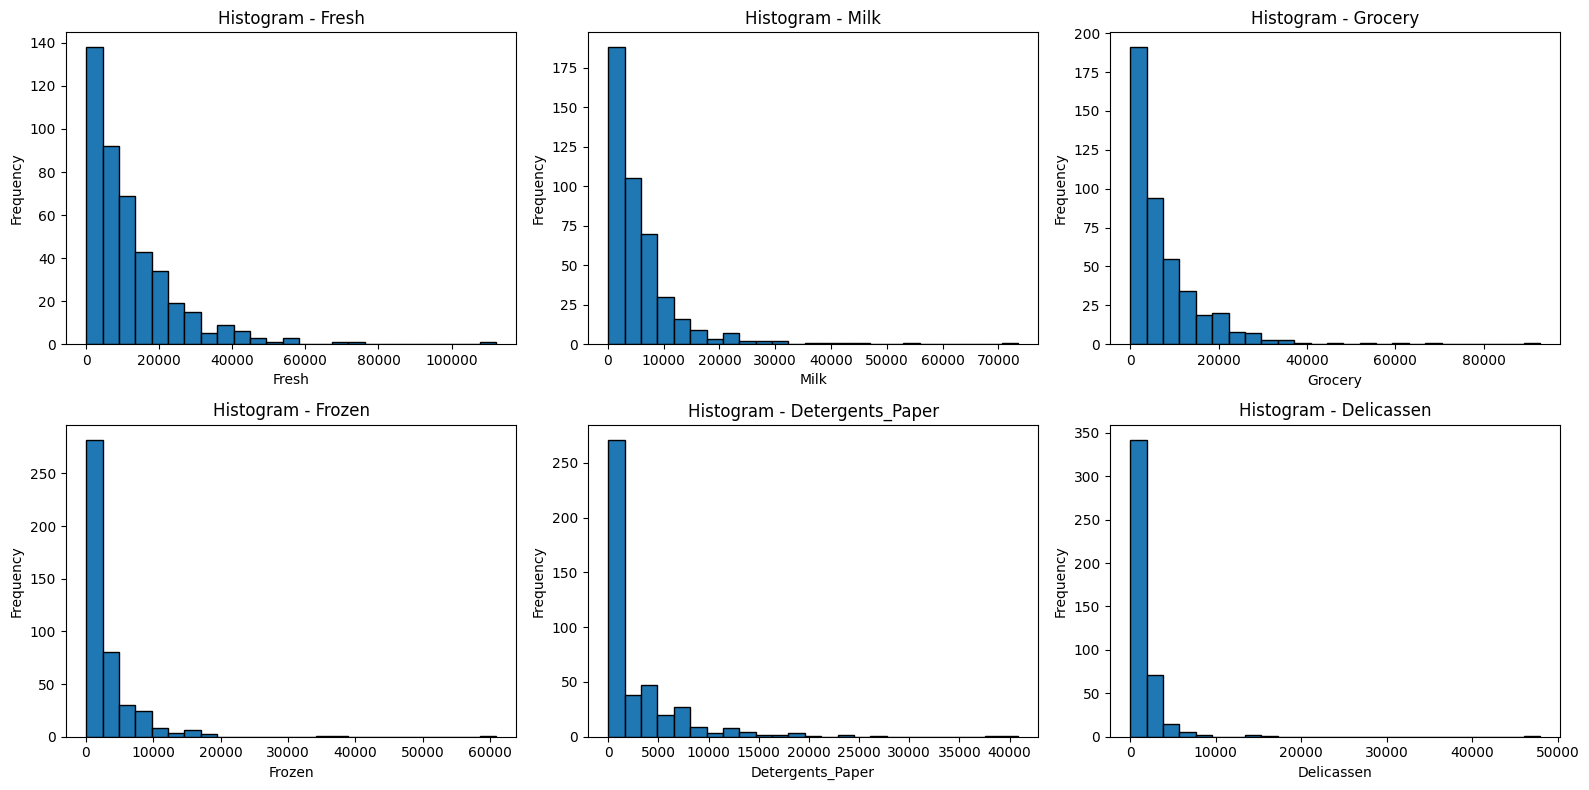

In [35]:
num_cols = X_raw.columns.tolist()

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    axes[i].hist(X_raw[col], bins=25, edgecolor="black")
    axes[i].set_title(f"Histogram - {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 6. Tiền xử lý dữ liệu

Với K-means, khoảng cách Euclid rất nhạy với:

- dữ liệu lệch mạnh
- chênh lệch thang đo giữa các đặc trưng

Do đó ta sẽ:

1. áp dụng `log1p` để giảm độ lệch
2. chuẩn hóa dữ liệu bằng z-score

In [36]:
X_log = np.log1p(X_raw)

class StandardScalerCustom:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.mean_) / self.std_

    def fit_transform(self, X):
        return self.fit(X).transform(X)

scaler = StandardScalerCustom()
X_scaled = scaler.fit_transform(X_log.values)

print("Shape sau tiền xử lý:", X_scaled.shape)
print("5 dòng đầu sau log + scale:")
pd.DataFrame(X_scaled, columns=spending_cols).head()

Shape sau tiền xử lý: (440, 6)
5 dòng đầu sau log + scale:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588


### 6.1. So sánh nhanh trước và sau biến đổi log

Biểu đồ dưới đây giúp quan sát dữ liệu sau `log1p`, thường sẽ bớt lệch hơn đáng kể.

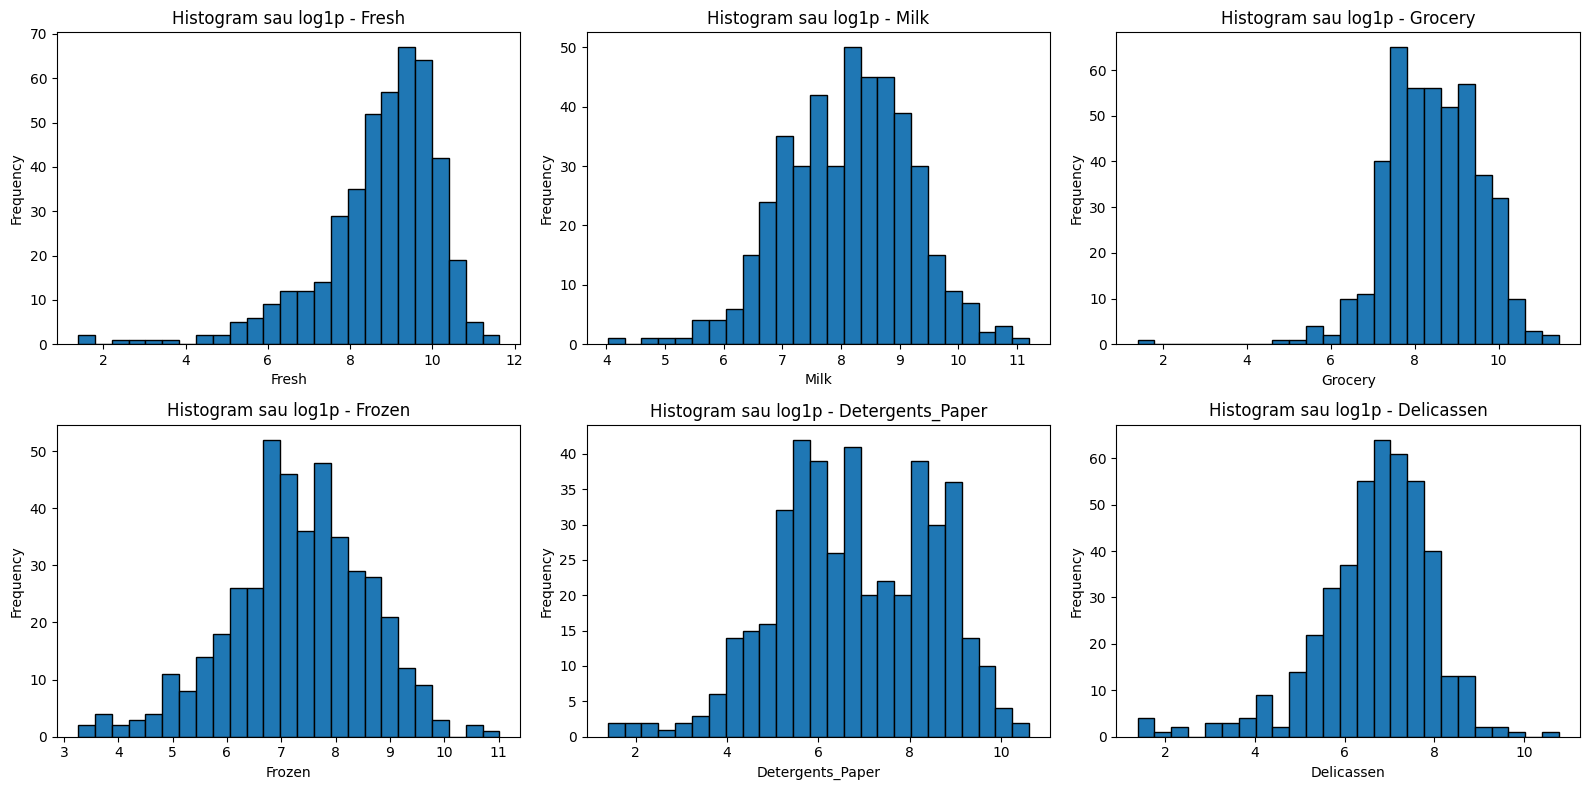

In [37]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    axes[i].hist(X_log[col], bins=25, edgecolor="black")
    axes[i].set_title(f"Histogram sau log1p - {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 7. Xây dựng mô hình K-means custom

- khởi tạo centroid ban đầu
- gán điểm vào centroid gần nhất
- cập nhật centroid theo trung bình cụm
- tính **WCSS** (Within-Cluster Sum of Squares)
- kiểm tra hội tụ

In [38]:
class CustomKMeans:
    def __init__(self, n_clusters=3, max_iters=100, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.tol = tol
        self.random_state = random_state

        self.centroids = None
        self.labels_ = None
        self.inertia_ = None
        self.history_ = []

    def _initialize_centroids(self, X):
        rng = np.random.default_rng(self.random_state)
        indices = rng.choice(len(X), size=self.n_clusters, replace=False)
        return X[indices].copy()    

    def _compute_distances(self, X, centroids):
        return np.linalg.norm(X[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
    
    def _assign_labels(self, X, centroids):
        distances = self._compute_distances(X, centroids)
        return np.argmin(distances, axis=1)

    def _update_centroids(self, X, labels, old_centroids):
        new_centroids = []
        for i in range(self.n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) == 0:
                new_centroids.append(old_centroids[i])
            else:
                new_centroids.append(cluster_points.mean(axis=0))
        return np.array(new_centroids)

    def _compute_wcss(self, X, labels, centroids):
        wcss = 0.0
        for i in range(self.n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                wcss += np.sum((cluster_points - centroids[i]) ** 2)
        return float(wcss) 

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        centroids = self._initialize_centroids(X)

        for iteration in range(self.max_iters):
            labels = self._assign_labels(X, centroids)
            new_centroids = self._update_centroids(X, labels, centroids)

            shift = np.linalg.norm(new_centroids - centroids)
            wcss = self._compute_wcss(X, labels, new_centroids)

            self.history_.append({
                "iteration": iteration + 1,
                "shift": shift,
                "wcss": wcss
            })

            if shift < self.tol:
                centroids = new_centroids
                break

            centroids = new_centroids

        self.centroids = centroids
        self.labels_ = self._assign_labels(X, self.centroids)
        self.inertia_ = self._compute_wcss(X, self.labels_, self.centroids)
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return self._assign_labels(X, self.centroids)

    def fit_predict(self, X):
        self.fit(X)
        return self.labels_

## 8. Chạy thử mô hình với một giá trị `K` mẫu

Phần này chỉ để kiểm tra mô hình custom hoạt động đúng trước khi đi vào Elbow Method.

In [39]:
sample_k = 3
sample_model = CustomKMeans(n_clusters=sample_k, max_iters=100, tol=1e-4, random_state=42)
sample_labels = sample_model.fit_predict(X_scaled)

print("K =", sample_k)
print("WCSS =", sample_model.inertia_)
print("Centroids shape =", sample_model.centroids.shape)

history_df = pd.DataFrame(sample_model.history_)
display(history_df.head())
display(history_df.tail())

K = 3
WCSS = 1619.3404248319598
Centroids shape = (3, 6)


,iteration,shift,wcss
0,1,2.828702,2029.960340
1,2,0.842961,1752.946941
2,3,0.480704,1670.902922
3,4,0.316530,1637.076844
4,5,0.162226,1627.144670


,iteration,shift,wcss
10,11,0.029366,1619.676707
11,12,0.027232,1619.494486
12,13,0.021987,1619.399823
13,14,0.023139,1619.340425
14,15,0.000000,1619.340425


## 9. Elbow Method để tìm `K` phù hợp

Ta thử nhiều giá trị `K` và ghi lại **WCSS**.  
Nguyên tắc:

- `K` tăng thì WCSS giảm
- chọn vị trí mà tốc độ giảm bắt đầu chậm lại rõ rệt
- đó là điểm "khuỷu tay" của đồ thị

In [40]:
k_values = list(range(1, 11))
wcss_values = []

for k in k_values:
    model = CustomKMeans(n_clusters=k, max_iters=100, tol=1e-4, random_state=42)
    model.fit(X_scaled)
    wcss_values.append(model.inertia_)

elbow_df = pd.DataFrame({
    "K": k_values,
    "WCSS": wcss_values
})

display(elbow_df)

,K,WCSS
0,1,2640.000000
1,2,1844.064069
2,3,1619.340425
3,4,1421.019012
4,5,1279.962410
5,6,1178.313787
6,7,1086.081051
7,8,1059.464337
8,9,1008.589488
9,10,942.113753


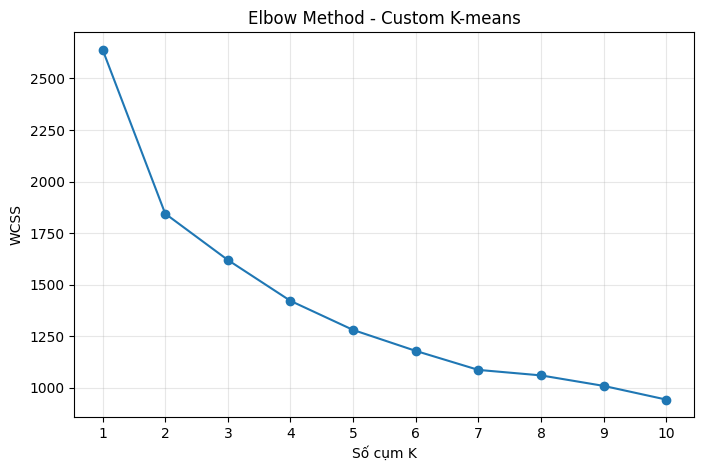

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss_values, marker="o")
plt.xticks(k_values)
plt.xlabel("Số cụm K")
plt.ylabel("WCSS")
plt.title("Elbow Method - Custom K-means")
plt.grid(True, alpha=0.3)
plt.show()

### 9.1. Gợi ý chọn `K`

Từ biểu đồ Elbow Method, ta thấy WCSS giảm mạnh từ K=1 đến K=3,
sau đó tốc độ giảm chậm lại.

Điều này cho thấy số cụm tối ưu hợp lý là K=3,
vì sau điểm này việc tăng số cụm không giúp cải thiện đáng kể độ chặt của cụm.

Do đó, ta chọn K = 3 cho mô hình K-means.

In [42]:
best_k = 3  
print("Giá trị K đang chọn:", best_k)

Giá trị K đang chọn: 3


## 10. Huấn luyện mô hình cuối cùng với `K` đã chọn

In [43]:
final_model = CustomKMeans(n_clusters=best_k, max_iters=100, tol=1e-4, random_state=42)
final_labels = final_model.fit_predict(X_scaled)

print("WCSS cuối cùng:", final_model.inertia_)
print("Số điểm trong từng cụm:")
print(pd.Series(final_labels).value_counts().sort_index())

WCSS cuối cùng: 1619.3404248319598
Số điểm trong từng cụm:
0     93
1    184
2    163
Name: count, dtype: int64


## 10.1. So sánh với mô hình `KMeans` của sklearn

Để kiểm tra mô hình custom có hoạt động hợp lý hay không, ta huấn luyện thêm mô hình `KMeans` từ `sklearn` với cùng số cụm `K`.

Ta sẽ so sánh:
- **WCSS / Inertia**
- **kích thước cụm**
- **tọa độ centroid**
- **phân bố cụm trên không gian PCA 2 chiều**

> Lưu ý: nhãn cụm của K-means có thể bị **đảo thứ tự** giữa hai mô hình. Vì vậy khi so sánh, ta quan tâm nhiều hơn đến chất lượng phân cụm và vị trí cụm, không chỉ nhìn số nhãn `0, 1, 2, ...`.


In [44]:
sklearn_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10,
    max_iter=300
)

sklearn_labels = sklearn_model.fit_predict(X_scaled)

print("WCSS custom:", final_model.inertia_)
print("WCSS sklearn:", sklearn_model.inertia_)
print()
print("Số điểm trong từng cụm - custom:")
print(pd.Series(final_labels).value_counts().sort_index())
print()
print("Số điểm trong từng cụm - sklearn:")
print(pd.Series(sklearn_labels).value_counts().sort_index())


WCSS custom: 1619.3404248319598
WCSS sklearn: 1553.4213271044873

Số điểm trong từng cụm - custom:
0     93
1    184
2    163
Name: count, dtype: int64

Số điểm trong từng cụm - sklearn:
0     80
1    147
2    213
Name: count, dtype: int64


### 10.2. So sánh centroid giữa hai mô hình


In [45]:
custom_centroids_df = pd.DataFrame(
    final_model.centroids,
    columns=spending_cols,
    index=[f"Custom Cluster {i}" for i in range(best_k)]
)

sklearn_centroids_df = pd.DataFrame(
    sklearn_model.cluster_centers_,
    columns=spending_cols,
    index=[f"Sklearn Cluster {i}" for i in range(best_k)]
)

print("Centroid của Custom K-means (trên dữ liệu đã scale):")
display(custom_centroids_df.round(4))

print("Centroid của Sklearn KMeans (trên dữ liệu đã scale):")
display(sklearn_centroids_df.round(4))


Centroid của Custom K-means (trên dữ liệu đã scale):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Custom Cluster 0,-0.5628,-0.7786,-0.6210,-0.6134,-0.6373,-1.0429
Custom Cluster 1,0.4707,-0.3582,-0.5024,0.6563,-0.5604,0.2474
Custom Cluster 2,-0.2102,0.8486,0.9215,-0.3908,0.9963,0.3158


Centroid của Sklearn KMeans (trên dữ liệu đã scale):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Sklearn Cluster 0,-1.1803,0.4774,0.6784,-1.1389,0.7833,-0.7011
Sklearn Cluster 1,0.4076,0.7987,0.7376,0.2958,0.6630,0.6824
Sklearn Cluster 2,0.1620,-0.7305,-0.7639,0.2236,-0.7518,-0.2076


### 10.3. Trực quan hóa cụm của hai mô hình trên PCA 2 chiều

Biểu đồ dưới đây giúp quan sát trực quan xem hai mô hình có chia dữ liệu theo cấu trúc tương tự nhau hay không.


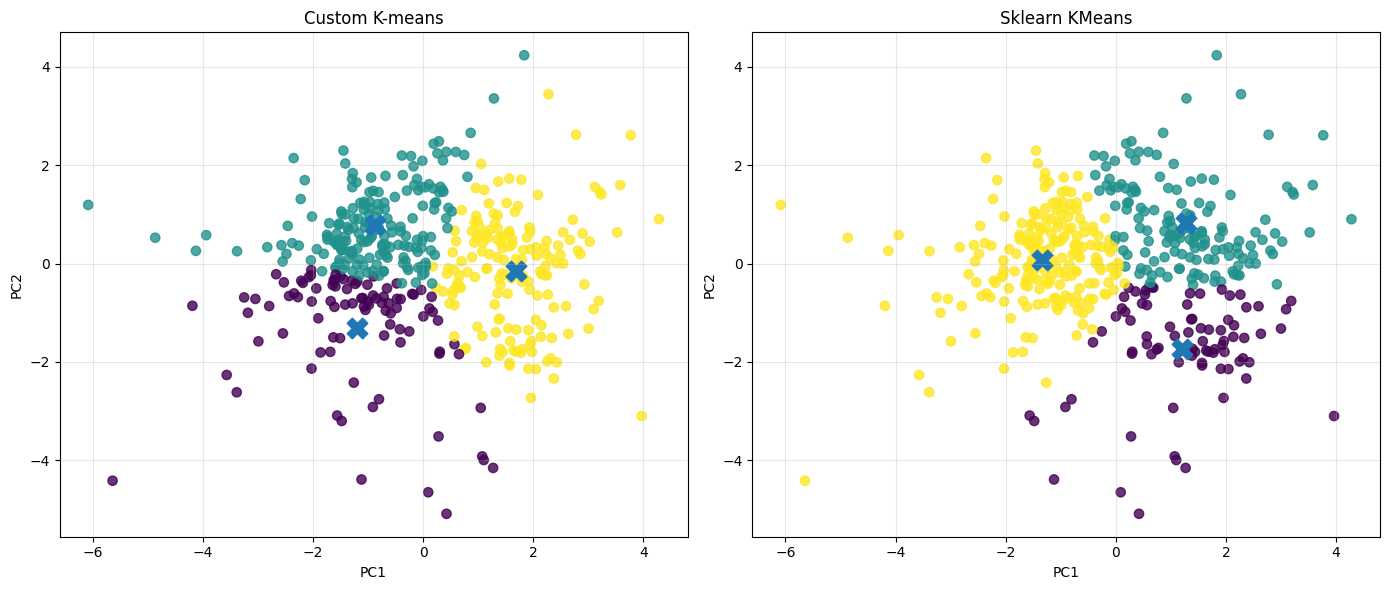

In [46]:
pca_compare = PCA(n_components=2, random_state=42)
X_pca_compare = pca_compare.fit_transform(X_scaled)

custom_centroids_pca = pca_compare.transform(final_model.centroids)
sklearn_centroids_pca = pca_compare.transform(sklearn_model.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca_compare[:, 0], X_pca_compare[:, 1], c=final_labels, s=45, alpha=0.8)
axes[0].scatter(custom_centroids_pca[:, 0], custom_centroids_pca[:, 1], marker="X", s=220)
axes[0].set_title("Custom K-means")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_pca_compare[:, 0], X_pca_compare[:, 1], c=sklearn_labels, s=45, alpha=0.8)
axes[1].scatter(sklearn_centroids_pca[:, 0], sklearn_centroids_pca[:, 1], marker="X", s=220)
axes[1].set_title("Sklearn KMeans")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 10.4. Nhận xét nhanh về phần so sánh

### Nhận xét so sánh Custom K-means và Sklearn KMeans

Từ hai biểu đồ trực quan hóa bằng PCA, có thể nhận thấy:

- Các cụm dữ liệu được phân chia khá tương đồng giữa hai mô hình.
- Vị trí các centroid (dấu X) gần như trùng nhau.
- Hình dạng và phân bố của các cụm không có sự khác biệt đáng kể.

Điều này cho thấy mô hình K-means tự cài đặt đã hoạt động đúng
và cho kết quả tương đương với thư viện sklearn.

Sự khác biệt nhỏ (nếu có) là do:
- Khởi tạo centroid ban đầu khác nhau
- Sklearn sử dụng nhiều lần khởi tạo (n_init) để tối ưu kết quả

Kết luận: Custom K-means là chính xác và đáng tin cậy.


## 11. Gắn nhãn cụm vào dữ liệu gốc

Bước này giúp ta dễ phân tích đặc trưng của từng cụm trên dữ liệu ban đầu.

In [47]:
df_clustered = df.copy()
df_clustered["Cluster"] = final_labels

display(df_clustered.head())

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,2
1,2,3,7057,9810,9568,1762,3293,1776,2
2,2,3,6353,8808,7684,2405,3516,7844,2
3,1,3,13265,1196,4221,6404,507,1788,1
4,2,3,22615,5410,7198,3915,1777,5185,1


## 12. Phân tích trung bình đặc trưng theo cụm

Ta xem giá trị trung bình của từng đặc trưng chi tiêu trong mỗi cụm để hiểu phong cách mua hàng.

In [48]:
cluster_profile = df_clustered.groupby("Cluster")[spending_cols].mean().round(2)
display(cluster_profile)

cluster_size = df_clustered["Cluster"].value_counts().sort_index().to_frame("count")
display(cluster_size)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,6934.09,2296.44,3516.51,1245.05,740.62,393.40
1,17069.67,3291.24,3505.58,5296.79,548.30,1741.09
2,9168.35,10620.86,15500.00,1602.77,6736.76,1926.36


,count
Cluster,
0,93
1,184
2,163


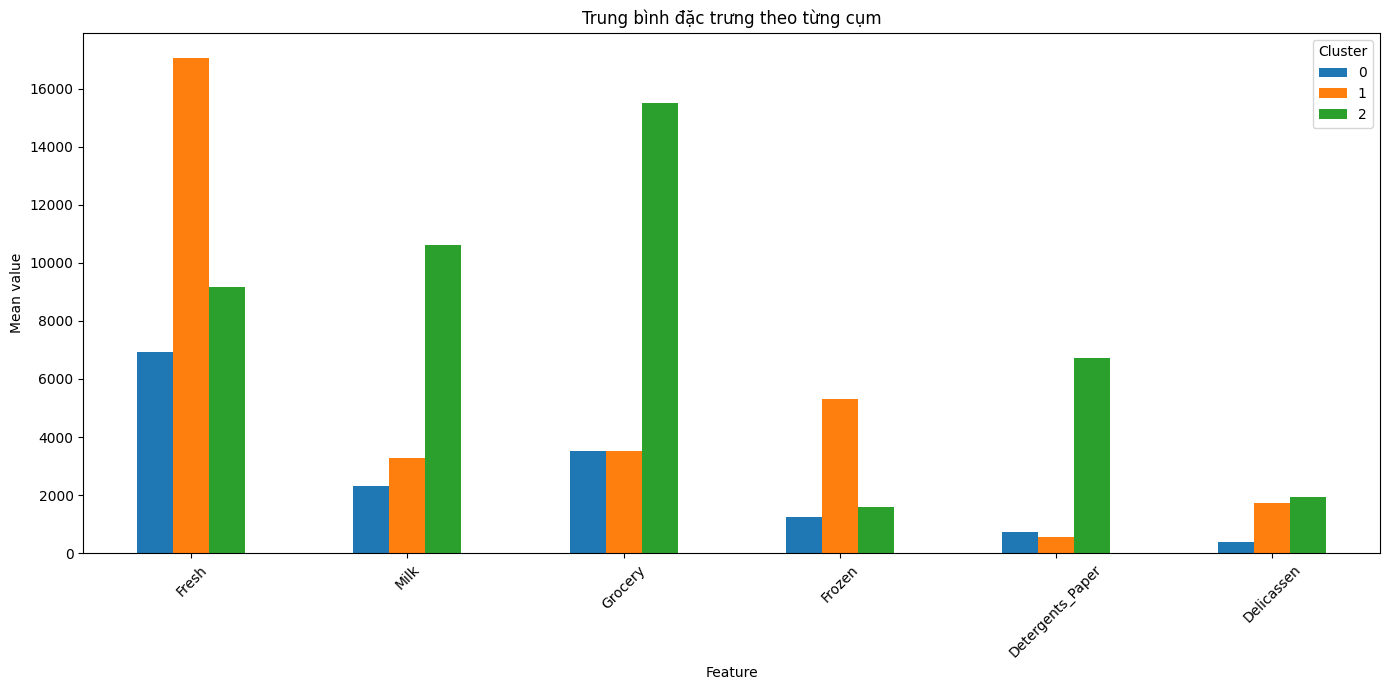

In [49]:
cluster_profile.T.plot(kind="bar", figsize=(14, 7))
plt.title("Trung bình đặc trưng theo từng cụm")
plt.xlabel("Feature")
plt.ylabel("Mean value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## 13. Phân tích `Channel` và `Region` theo cụm

Mặc dù không đưa `Channel` và `Region` trực tiếp vào K-means, ta vẫn có thể dùng chúng để **diễn giải** kết quả phân cụm.

In [50]:
if "Channel" in df_clustered.columns:
    print("Phân bố Channel theo cụm:")
    display(pd.crosstab(df_clustered["Cluster"], df_clustered["Channel"]))

if "Region" in df_clustered.columns:
    print("Phân bố Region theo cụm:")
    display(pd.crosstab(df_clustered["Cluster"], df_clustered["Region"]))

Phân bố Channel theo cụm:


Channel,1,2
Cluster,,
0,86,7
1,176,8
2,36,127


Phân bố Region theo cụm:


Region,1,2,3
Cluster,,,
0,16,7,70
1,35,22,127
2,26,18,119


## 14. Trực quan hóa cụm bằng PCA 2 chiều

Do dữ liệu gốc có nhiều chiều, ta dùng **PCA** để chiếu dữ liệu xuống 2 chiều và quan sát phân bố cụm một cách trực quan hơn.

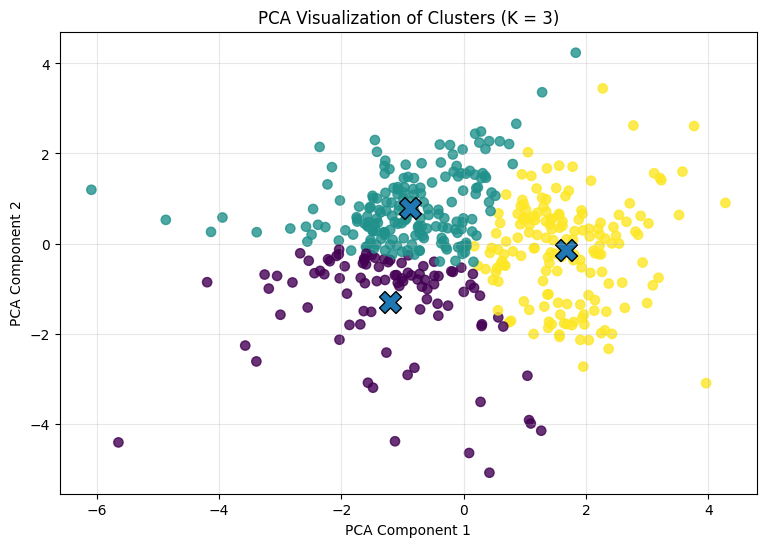

In [51]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

centroids_pca = pca.transform(final_model.centroids)

plt.figure(figsize=(9, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, s=45, alpha=0.8)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker="X", s=250, edgecolors="black")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title(f"PCA Visualization of Clusters (K = {best_k})")
plt.grid(True, alpha=0.3)
plt.show()

## Diễn giải các cụm khách hàng

Dựa trên kết quả phân cụm với K = 3 và trực quan hóa bằng PCA, ta có thể nhận thấy:

- Cụm màu vàng: đại diện cho nhóm khách hàng có mức chi tiêu cao hơn,
  có thể là các cửa hàng lớn hoặc khách hàng mua hàng với khối lượng lớn.

- Cụm màu xanh: nhóm khách hàng có mức chi tiêu trung bình,
  hành vi mua hàng tương đối cân bằng giữa các loại sản phẩm.

- Cụm màu tím: nhóm khách hàng có mức chi tiêu thấp,
  có thể là khách hàng nhỏ hoặc ít mua hàng.

Việc phân cụm này giúp doanh nghiệp hiểu rõ hơn về hành vi khách hàng
để đưa ra các chiến lược marketing và chăm sóc phù hợp.

## 15. Tỷ lệ phương sai giải thích của PCA

In [52]:
explained_variance = pca.explained_variance_ratio_
print("Tỷ lệ phương sai giải thích của PC1 và PC2:", explained_variance)
print("Tổng phương sai giải thích:", explained_variance.sum())

Tỷ lệ phương sai giải thích của PC1 và PC2: [0.44077752 0.27194917]
Tổng phương sai giải thích: 0.7127266893428759


## 16. Diễn giải kết quả cụm

Khi xem bảng trung bình đặc trưng theo cụm, bạn có thể diễn giải theo hướng:

- cụm có `Grocery`, `Milk`, `Detergents_Paper` cao: có thể nghiêng về nhóm khách hàng bán lẻ
- cụm có `Fresh`, `Frozen` cao: có thể nghiêng về nhóm khách hàng nhà hàng / khách sạn / dịch vụ ăn uống
- cụm có mức chi tiêu thấp ở hầu hết cột: có thể là nhóm khách hàng quy mô nhỏ

Đây là bước rất quan trọng vì bài toán clustering không có nhãn đúng/sai cố định, nên ý nghĩa của cụm cần được rút ra từ dữ liệu.

## 17. Kết luận

Notebook đã hoàn thành các bước:

- xử lý dữ liệu Wholesale Customers
- chuẩn hóa dữ liệu phù hợp với K-means
- xây dựng mô hình **K-means custom**
- áp dụng **Elbow Method** để tìm số cụm `K`
- so sánh mô hình custom với **KMeans của sklearn**
- huấn luyện mô hình cuối cùng
- trực quan hóa và diễn giải cụm khách hàng

In [53]:
import sys
import pandas as pd
import numpy as np
import sklearn
import gradio
import joblib
import pickle

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("gradio:", gradio.__version__)
print("joblib:", joblib.__version__)


Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
pandas: 2.3.2
numpy: 2.3.3
scikit-learn: 1.7.2
gradio: 5.49.1
joblib: 1.5.2
